# Notebook for some tests
This notebook will contain tests and some early results. I will keep some of the results on this notebook but mote likely will expand onto new more developed notebooks on the future.

In [ ]:
import os
os.chdir("..")


---

# Hack para usar Google Colab para ejecutar todo
Si se esta usando una instancia de google colab hay que clonar el repo

In [32]:
!git clone https://github.com/felisan99/inverted-pendulum.git

fatal: destination path 'inverted-pendulum' already exists and is not an empty directory.


In [ ]:
!pip install -r inverted-pendulum/requirements.txt 

In [2]:
import sys
sys.path.append("./inverted-pendulum")

---

In [ ]:
import importlib
import agents.trainer
importlib.reload(agents.trainer)
from agents.trainer import RLTrainer

In [6]:
trainer = RLTrainer(
    agent_type="PPO",
    xml_file="mujoco_sim/xml_models/pendulum_model_v2.xml",
    render_mode=None,
    max_steps=5000,
    seed=40,
    policy="MlpPolicy",
    task="swing_up",
    agent_kwargs={
        "learning_rate": 3e-4,
        "gamma": 0.99,
        "n_steps": 2048,
        "batch_size": 64,
    }
)

In [7]:
trainer.train(total_timesteps=2_000_000)

Directorio de resultados: results/run_6
Entrenando PPO por 2000000 pasos.
Eval num_timesteps=5000, episode_reward=178.03 +/- 0.00
Episode length: 5000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=10000, episode_reward=975.03 +/- 0.00
Episode length: 5000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=15000, episode_reward=1126.40 +/- 0.00
Episode length: 5000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=20000, episode_reward=1538.72 +/- 0.00
Episode length: 5000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=25000, episode_reward=2801.23 +/- 0.00
Episode length: 5000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=30000, episode_reward=2689.14 +/- 0.00
Episode length: 5000.00 +/- 0.00
Eval num_timesteps=35000, episode_reward=2269.02 +/- 0.00
Episode length: 5000.00 +/- 0.00
Eval num_timesteps=40000, episode_reward=2812.66 +/- 0.00
Episode length: 5000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=45000, episode_reward=3100.42 +/- 0.00
Episode len

KeyboardInterrupt: 

Ganancias K:
 [[-4.47213596e-01  1.70186970e+02 -1.66692211e+00  3.72637851e+01
   4.85563469e-02]]


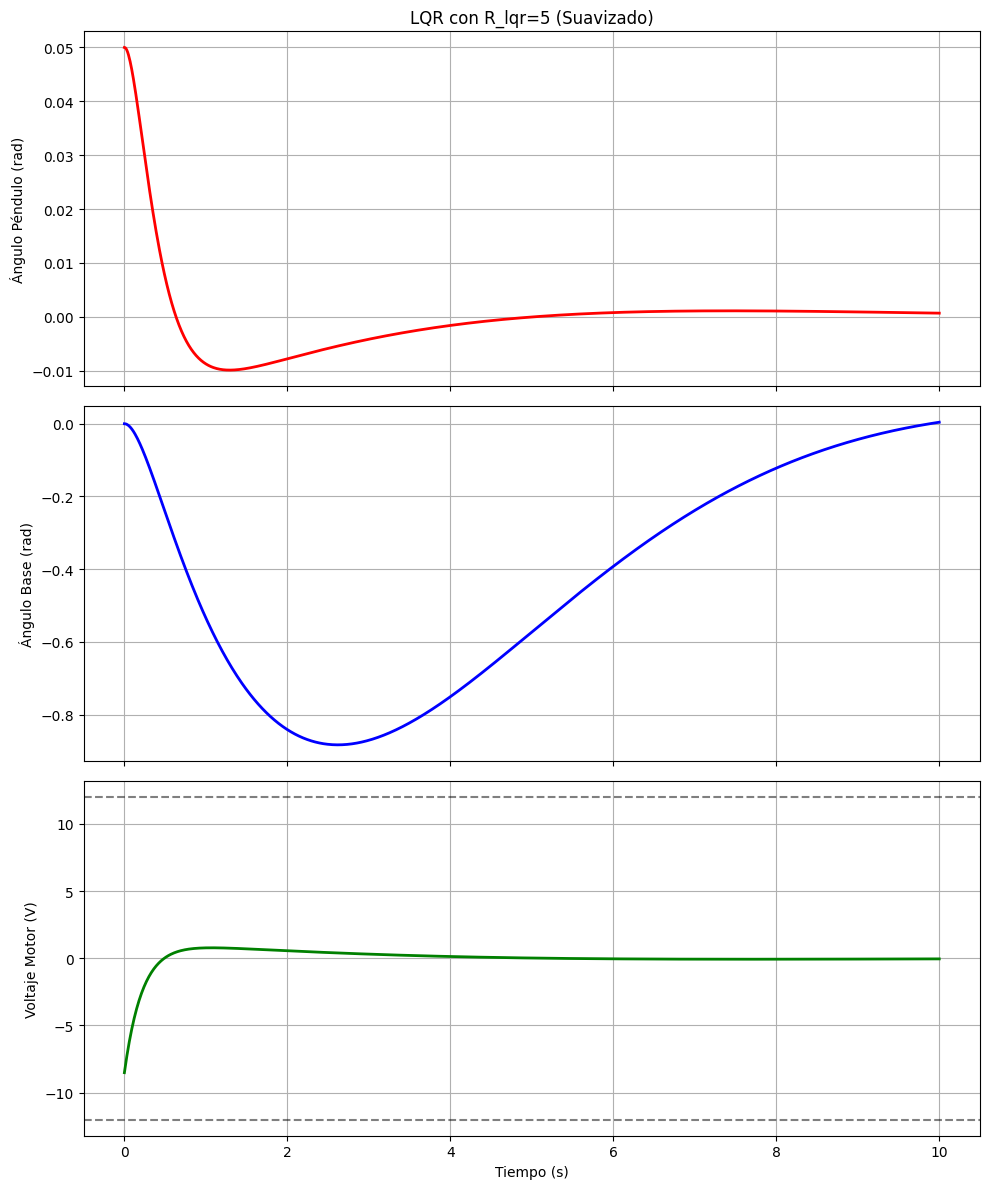

Voltaje Máximo Usado: 8.51 V


In [3]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt
plt.close('all')

# --- 1. PARÁMETROS FÍSICOS ---
L1, l1 = 0.278, 0.150
L2, l2 = 0.300, 0.148
m1, m2 = 0.300, 0.075
J1, J2 = 2.48e-2, 3.86e-3
b1, b2 = 1.00e-4, 2.80e-4


Rm = 5      # Resistencia del Motor (Ohms)
L_motor = 0.005
Km = 0.090
g = 9.81

# Cálculos intermedios
J_hat_1 = J1 + m1 * l1**2
J_hat_2 = J2 + m2 * l2**2
J_hat_0 = J_hat_1 + m2 * L1**2
Denom = J_hat_0 * J_hat_2 - (m2 * L1 * l2)**2

# --- 2. CONSTRUCCIÓN DE MATRICES ---
# Calculamos los términos Aij
A32 = (g * m2**2 * l2**2 * L1) / Denom
A33 = -(b1 * J_hat_2) / Denom
A34 = -(b2 * m2 * l2 * L1) / Denom
A42 = (g * m2 * l2 * J_hat_0) / Denom
A43 = -(b1 * m2 * l2 * L1) / Denom
A44 = -(b2 * J_hat_0) / Denom

B31_mec = (J_hat_2) / Denom
B41_mec = (m2 * l2 * L1) / Denom

# Matriz A (5x5)
# OJO: Usamos 'Rm' (7.8) aquí, NO la matriz del LQR
A = np.array([
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0],
    [0, A32, A33, A34, B31_mec * Km],
    [0, A42, A43, A44, B41_mec * Km],
    [0, 0, -Km/L_motor, 0, -Rm/L_motor] 
])

# Matriz B (5x1)
B = np.array([[0], [0], [0], [0], [1/L_motor]])

# --- 3. DISEÑO DEL LQR (Sintonización) ---
# Diagonal de pesos Q: [Pos_Base, Pos_Pendulo, Vel_Base, Vel_Pendulo, Corriente]
Q = np.diag([1, 10, 0.1, 0.1, 0.01])

# Peso R del LQR (Costo de Energía)
# PRUEBA: Con 50 o 100 debería bajar el voltaje considerablemente.
R_lqr = np.array([[5]]) 

# Calculamos K usando las variables correctas
K, S, E = ct.lqr(A, B, Q, R_lqr)

print("Ganancias K:\n", K)

# --- 4. SIMULACIÓN ---
# Crear sistema en lazo cerrado
sys_cl = ct.ss(A - B @ K, B, np.eye(5), 0)

# Simular 10 segundos
t = np.linspace(0, 10, 1000)
x0 = [0, 0.05, 0, 0, 0] # ~2.8 grados

# Respuesta
t, y = ct.forced_response(sys_cl, T=t, U=0, X0=x0)

# Calcular voltaje
U_control = -K @ y 

# --- GRAFICAR ---
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Péndulo
axs[0].plot(t, y[1], 'r', linewidth=2)
axs[0].set_ylabel("Ángulo Péndulo (rad)")
axs[0].set_title(f"LQR con R_lqr={R_lqr[0,0]} (Suavizado)")
axs[0].grid(True)

# Base
axs[1].plot(t, y[0], 'b', linewidth=2)
axs[1].set_ylabel("Ángulo Base (rad)")
axs[1].grid(True)

# Voltaje
axs[2].plot(t, U_control[0], 'g', linewidth=2)
axs[2].set_ylabel("Voltaje Motor (V)")
axs[2].set_xlabel("Tiempo (s)")
axs[2].grid(True)

# Límites
axs[2].axhline(y=12, color='k', linestyle='--', alpha=0.5)
axs[2].axhline(y=-12, color='k', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Imprimir voltaje máximo usado
print(f"Voltaje Máximo Usado: {np.max(np.abs(U_control)):.2f} V")